# greedy k-center デモノートブック（日本語）

このノートブックは、SIMPL プロジェクト内のトレインデータからランダムに数百件を抽出し、
greedy k-center（farthest-first traversal）アルゴリズムを実行して代表サンプルを選ぶデモです。

実行手順（簡潔）:
1. リポジトリルートで Jupyter を起動する（`jupyter lab` / `jupyter notebook`）。
2. `notebooks/greedy_k_center_demo.ipynb` を開いてセルを上から実行する。

注意: このノートブックは環境依存（Loaderやデータ構造）なので、`extract_feature()` をデータの中身に合わせて調整してください。


## 概要

- 目的: 小さなデータサブセット（デフォルトで300件）に対して、greedy k-center（遠心点選択）を実行し、代表的な k 個を選ぶ。
- アルゴリズム: farthest-first traversal（各ステップで既存のセンターからの最短距離が最大の点を選ぶ）
- 出力: 選ばれたサンプルのインデックスを `notebooks/selected_indices_k{K}.json` に保存する。

次のセルでは依存ライブラリをインポートします。

In [1]:
# 必要なライブラリをインポート
import os
import json
import random
from pathlib import Path

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# sklearn は任意（PCAで可視化するため）
try:
    from sklearn.decomposition import PCA
except Exception:
    PCA = None

# repo のトップレベルにある loader を使うためにパスを通す
import sys
repo_root = Path(os.getcwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from loader import Loader

print('PCA available:', PCA is not None)
print('Repo root:', repo_root)


PCA available: True
Repo root: /home/tucker/dev/SIMPL


/home/tucker/miniconda3/envs/simpl-py39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## データ読み込みと特徴抽出ヘルパー

このセルは、Loader からランダムに N 件をサンプリングし、
各サンプルからベクトル特徴量を抽出するヘルパー関数を定義します。

注意: プロジェクトのデータフォーマットに合わせて `extract_feature()` を編集してください。


In [12]:
from types import SimpleNamespace
from pathlib import Path
import torch

def sample_dataset(loader_cfg_name: str = 'config/simpl_cfg.py', N: int = 300, seed: int = 0):
    """Loader を使ってデータセットからランダムに N 件を返す。

    loader_cfg_name: loader が期待する設定ファイルパス（リポジトリ相対）
    N: サンプリング数
    """
    random.seed(seed)
    np.random.seed(seed)

    # Loader の初期化はプロジェクトの使い方に合わせて調整してください。
    # ここではデフォルトの設定ファイル名を渡して Loader を作る例を示します。

    args = SimpleNamespace(
			adv_cfg_path='config.simpl_cfg',  # ← module path (no .py)
			features_dir=str(Path.cwd() / 'data_argo/features') + '/',  # ← 実際の features ディレクトリに合わせて
			mode='train',
			data_aug=False
		)

    device = torch.device("cuda", 0)

    loader = Loader(args, device, is_ddp=False)
    (train_set, _), net, loss_fn, optimizer, evaluator = loader.load()

    total = len(train_set)
    if N >= total:
        indices = list(range(total))
    else:
        indices = random.sample(range(total), N)

    samples = [train_set[i] for i in indices]
    return samples, indices


def extract_feature(sample):
    """サンプルから固定長の特徴ベクトルを作る。プロジェクトのデータ構造に合わせて編集してください。

    現在の実装（推奨の開始点）:
    - 最後の観測位置 (x,y)
    - 最後の観測速度 (vx, vy)（もし利用可能なら）
    - 未来軌跡の最初 K 点を平坦化（任意）
    """
    # サンプルの中身を確認してからこの関数を編集してください。
    # ここではよくあるフォーマットを仮定したダミー実装を置きます。
    try:
        obs = sample['TRAJS']  # shape (T_obs, 2)
        last_pos = obs[-1]
        if 'VELS' in sample:
            last_vel = sample['VELS'][-1]
        else:
            # 近似: 差分で速度を計算
            last_vel = obs[-1] - obs[-2]

        # フラットなベクトル
        feat = np.concatenate([np.asarray(last_pos).ravel(), np.asarray(last_vel).ravel()])
        return feat.astype(float)
    except Exception as e:
        # 失敗した場合はゼロベクトルを返す（デバッグ用）
        return np.zeros(4, dtype=float)


# 小さく動作確認するヘルパー
samples, sample_indices = None, None


### 診断セル — サンプルの中身を確認

まず、取得した `samples` の典型的な要素を確認して、どのフィールドを特徴量化に使えるか見ます。次のセルを実行して、サンプルのキー、型、軸数を確認してください。

In [ ]:
# Cell: サンプルの診断
if samples is None:
    samples, sample_indices = sample_dataset(loader_cfg_name=CFG, N=50, seed=SEED)

print('num samples (diagnostic):', len(samples))
if len(samples) > 0:
    s0 = samples[0]
    print('keys:', list(s0.keys()))
    for k,v in s0.items():
        try:
            import numpy as _np
            arr = _np.asarray(v)
            print(f"{k}: type={type(v)}, shape={arr.shape}, dtype={arr.dtype}")
        except Exception as e:
            print(f"{k}: type={type(v)}, repr_len={len(repr(v))}")


### 改良された特徴抽出 + 前処理
- 各サンプルからより多くの情報を平坦化して取り出す（観測系列の位置、速度、未来軌跡の一部など）
- 平均0・分散1 に標準化（StandardScaler 相当に）
- 必要なら PCA で次元削減して k-center に渡す

In [ ]:
def extract_feature_rich(sample, use_future_k=3):
    """より豊かな特徴量を作って返す。返り値は 1D numpy array。

    - 観測系列 (T_obs, 2) をフラット化 (x0,y0, x1,y1, ...)
    - 観測速度（差分）をフラット化
    - 未来軌跡があれば最初 use_future_k 点をフラット化
    - 距離ノルムなどの統計量（mean, std）
    """
    try:
        obs = np.asarray(sample['TRAJS'])  # (T_obs, 2)
        feat_list = []
        # obs positions flattened
        feat_list.append(obs.ravel())
        # obs diffs (velocity approx)
        if obs.shape[0] >= 2:
            diffs = np.diff(obs, axis=0)
            feat_list.append(diffs.ravel())
        # future traj if present
        if 'TRAJS_FUT' in sample:
            fut = np.asarray(sample['TRAJS_FUT'])
            k = min(use_future_k, fut.shape[0])
            feat_list.append(fut[:k].ravel())
        # simple statistics
        feat_list.append(np.array([np.linalg.norm(obs, axis=1).mean(), np.linalg.norm(obs, axis=1).std()]))

        # concat and return
        vec = np.concatenate([np.asarray(x).ravel() for x in feat_list]).astype(float)
        return vec
    except Exception as e:
        return np.zeros(8, dtype=float)

from sklearn.preprocessing import StandardScaler

def prepare_feature_matrix(samples, feature_fn=extract_feature_rich, pca_n=32):
    X = np.vstack([feature_fn(s) for s in samples])
    # standardize
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    if pca_n is not None and PCA is not None:
        pca_n = min(pca_n, Xs.shape[1])
        if pca_n < Xs.shape[1]:
            pca = PCA(n_components=pca_n)
            Xs = pca.fit_transform(Xs)
    return Xs, scaler


### 重複を避ける堅牢な greedy k-center と実行セル
- greedy_k_center が同じ点を何度も選ばないように改良
- 特徴行列を作って PCA/標準化を行った上で選択する
- 選択後に保存・可視化

In [ ]:
def greedy_k_center_no_duplicates(X: np.ndarray, k: int, seed: int = 0):
    N = X.shape[0]
    if k >= N:
        return list(range(N))
    rng = np.random.RandomState(seed)
    # choose first randomly among unique rows
    first = rng.randint(0, N)
    centers = [int(first)]
    # distances to nearest center
    dists = np.linalg.norm(X - X[first], axis=1)
    selected = set(centers)
    for _ in range(1, k):
        # mask already selected
        dists_masked = np.copy(dists)
        for s in selected:
            dists_masked[s] = -1  # so argmax won't pick
        idx = int(np.argmax(dists_masked))
        if dists_masked[idx] <= 0:
            # all remaining distances are 0 or negative -> pick any not selected
            for cand in range(N):
                if cand not in selected:
                    idx = cand
                    break
        centers.append(idx)
        selected.add(idx)
        new_d = np.linalg.norm(X - X[idx], axis=1)
        dists = np.minimum(dists, new_d)
    return centers

# 実行用セル（改良版）
N_SAMPLE = 300
K = 50
SEED = 0

samples, sample_indices = sample_dataset(loader_cfg_name=CFG, N=N_SAMPLE, seed=SEED)
print('sampled', len(samples))
Xr, scaler = prepare_feature_matrix(samples, feature_fn=extract_feature_rich, pca_n=16)
print('feature matrix after preprocessing shape:', Xr.shape)
centers = greedy_k_center_no_duplicates(Xr, k=K, seed=SEED)
print('selected centers:', centers[:10])
selected_dataset_indices = [sample_indices[i] for i in centers]
print('selected global:', selected_dataset_indices[:10])
with open(Path('notebooks') / f'selected_indices_k{K}_rich.json', 'w') as f:
    json.dump({'k':K, 'selected_local':centers, 'selected_global': selected_dataset_indices}, f, indent=2)
print('saved to', Path('notebooks') / f'selected_indices_k{K}_rich.json')


## greedy k-center（farthest-first）実装

次に、greedy k-center アルゴリズムを実装します。時間計算量は O(kN)（距離行列を繰り返し更新）です。小さな N（数百）では十分高速です。

In [10]:
def greedy_k_center(X: np.ndarray, k: int, seed: int = 0):
    """Greedy k-center selection (farthest-first).

    X: (N, D) データ行列
    k: 選択するセンター数
    戻り値: 選択されたインデックスのリスト（長さ k）
    """
    assert X.ndim == 2
    N = X.shape[0]
    if k >= N:
        return list(range(N))

    rng = np.random.RandomState(seed)
    centers = []
    # 初期点をランダムに選ぶ
    first = rng.randint(0, N)
    centers.append(first)

    # 各点と最近接センターの距離を保持
    dists = np.linalg.norm(X - X[first], axis=1)

    for _ in range(1, k):
        # 次は既存センターからの距離が最大の点
        idx = int(np.argmax(dists))
        centers.append(idx)
        # 新しく選ばれたセンターとの距離で最短距離を更新
        new_d = np.linalg.norm(X - X[idx], axis=1)
        dists = np.minimum(dists, new_d)

    return centers

# 距離行列を事前に計算するバージョン（メモリ使用が許される場合）
def greedy_k_center_distmat(X: np.ndarray, k: int, seed: int = 0):
    N = X.shape[0]
    if k >= N:
        return list(range(N))
    rng = np.random.RandomState(seed)
    centers = [rng.randint(0, N)]
    # 距離行列
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))
    min_d = D[centers[0]]
    for _ in range(1, k):
        idx = int(np.argmax(min_d))
        centers.append(idx)
        min_d = np.minimum(min_d, D[idx])
    return centers


## 実行 — サンプル作成、特徴抽出、k-center 選択

ここで実行パラメータを設定し、ノートブックを動かしてみます。

In [15]:
# パラメータ
N_SAMPLE = 10000
K = 50
SEED = 0
CFG = 'config.simpl_cfg'  # 必要に応じて変更

# サンプルを取得
samples, sample_indices = sample_dataset(loader_cfg_name=CFG, N=N_SAMPLE, seed=SEED)
print(f"sampled {len(samples)} items from dataset")

# 特徴ベクトル化
X = np.vstack([extract_feature(s) for s in samples])
print('feature matrix shape:', X.shape)

# k-center 選択
centers = greedy_k_center(X, k=K, seed=SEED)
print('selected centers (local indices):', centers[:10], '...')

# 選択したサンプルの元の dataset インデックス
selected_dataset_indices = [sample_indices[i] for i in centers]
print('selected dataset indices (global):', selected_dataset_indices[:10], '...')

# 保存
out_path = Path('notebooks') / f'selected_indices_k{K}.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w') as f:
    json.dump({'k': K, 'selected_local': centers, 'selected_global': selected_dataset_indices}, f, indent=2)
print('saved to', out_path)


[Loader] load adv_cfg from config.simpl_cfg
[Loader] load dataset ArgoDataset from simpl.av1_dataset
[Dataset] preparing /home/tucker/dev/SIMPL/data_argo/features/train/
[Dataset] Dataset Info:
-- mode:  train
-- total frames:  205942
-- obs_len:  20
-- pred_len:  30
-- seq_len:  50
-- aug:  False
[Dataset] preparing /home/tucker/dev/SIMPL/data_argo/features/val/
[Dataset] Dataset Info:
-- mode:  val
-- total frames:  39472
-- obs_len:  20
-- pred_len:  30
-- seq_len:  50
-- aug:  False
[Loader] load network Simpl from simpl.simpl
[Loader] network params:
-- total: 1827965
-- pred_net 422461
-- lane_net 169088
-- fusion_net 813696
-- actor_net 422720
[Loader] loading loss LossFunc from simpl.av1_loss_fn
sampled 10000 items from dataset
feature matrix shape: (10000, 4)
selected centers (local indices): [2732, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
selected dataset indices (global): [76448, 100989, 100989, 100989, 100989, 100989, 100989, 100989, 100989, 100989] ...
saved to notebooks/selected_in

## 可視化（任意, PCA を使用）

PCA が利用可能ならば、2 次元に射影して散布図を表示します。選ばれた点は赤でマーク。

/home/tucker/miniconda3/envs/simpl-py39/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:648: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


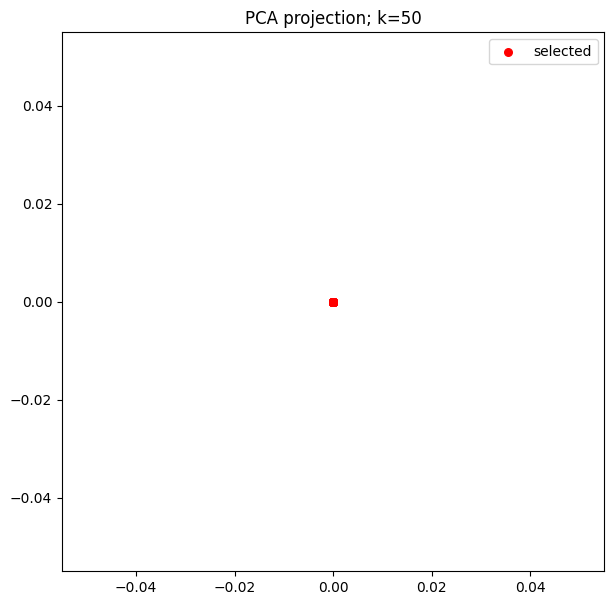

In [14]:
if PCA is not None:
    try:
        pca = PCA(n_components=2)
        Z = pca.fit_transform(X)
        plt.figure(figsize=(7,7))
        plt.scatter(Z[:,0], Z[:,1], s=10, alpha=0.6)
        plt.scatter(Z[centers,0], Z[centers,1], c='red', s=30, label='selected')
        plt.title(f'PCA projection; k={K}')
        plt.legend()
        plt.show()
    except Exception as e:
        print('PCA visualization failed:', e)
else:
    print('sklearn not available; skipping PCA visualization')


## 次のステップとカスタマイズ案

- extract_feature を実データに合わせて改善する（座標系列、速度、周囲のエージェント統計、レーン情報など）
- 距離尺度を変える（L2 以外、重み付き距離）
- 大規模データセットでは近似 k-center（例えば kmeans++ の初期化や近似最近傍）を検討
- このノートブックをスクリプト化して CI/バッチで選択を再現可能にする

以上。必要ならこのノートブックをベースに extract_feature を具体化しておきます。